# PCA Ablation: Input Dimensionality vs Expert Performance

Sweep number of PCA components to control task difficulty.
PCA is fit on train split only to avoid leakage.

In [1]:
import sys
import os
from pathlib import Path

# Ensure CWD is liquid_jax/ so relative paths in Mnist resolve correctly
_liquid_jax = Path(__file__).resolve().parent.parent if "__file__" in dir() else Path(os.getcwd()).parent
os.chdir(_liquid_jax)
sys.path.insert(0, str(_liquid_jax))

from datetime import datetime
import yaml
import pandas as pd
import numpy as np
import jax
import jax.numpy as jnp
import tqdm
import matplotlib.pyplot as plt

from mnist_pca import make_pca_task
from liquid_solver import LEsolver, LEInfo
from learner_base import Learner
from structs import TrainParams
from train import train
from run_ablation_experiment import (
    LeMlpSkip, count_component_params, solve_head_hidden,
)

In [18]:
# Config
N_COMPONENTS_VALUES = [1 , 2 ,4, 784]
PAD_TO = 784  # zero-pad all inputs to this width so architecture + params are identical
N_MODELS = 10
N_CLASSES = 10
EPOCHS = 20
LR = 1e-3
BATCH_SIZE = 512
SEED = 42

# Fixed architecture for all runs — set these manually
H_BODY = 10
BODY_OUT_DIM = 64
H_OUT = 10
H_DEL = 10

In [19]:
solver = LEsolver(
    load_distribution_lambda=0.1,
    specialization_lambda=0,
)

BODY = (H_BODY, BODY_OUT_DIM)
OUT = (H_OUT, N_CLASSES)
DELEGATION = (H_DEL, N_MODELS)


def make_learner(n_models, body, out, delegation):
    class _Learner(Learner[LEInfo]):
        @staticmethod
        def get_model():
            return LeMlpSkip(
                n_models=n_models, body=body, out=out,
                delegation=delegation, skip=False,
            )

        @staticmethod
        def forward(key, x, model, params):
            ys, deleg = model.apply({"params": params}, x)
            leinfo = solver.solve_power(deleg)
            y = solver.mix_power_logits(ys, leinfo.power)
            return y, leinfo

        @staticmethod
        def auxillary_losses(key, train_return):
            return {
                "load_distribution_loss": solver.load_distribution_loss(train_return),
                "specialization_losss": solver.specialization_loss(train_return),
            }

    return _Learner

## Print configs to verify param distribution

In [20]:
# Verify: all runs have identical param count with padding
body_params = count_component_params(PAD_TO, H_BODY, BODY_OUT_DIM)
out_params = count_component_params(BODY_OUT_DIM, H_OUT, N_CLASSES)
del_params = count_component_params(BODY_OUT_DIM, H_DEL, N_MODELS)
total = body_params + out_params + del_params
print(f"Fixed architecture: body={BODY}, out={OUT}, delegation={DELEGATION}")
print(f"Input padded to {PAD_TO} for all runs")
print(f"Per-expert params: body={body_params} + out={out_params} + del={del_params} = {total}")

Fixed architecture: body=(10, 64), out=(10, 10), delegation=(10, 10)
Input padded to 784 for all runs
Per-expert params: body=8554 + out=760 + del=760 = 10074


## Run the sweep

In [21]:
exp_dir = f"../experiments/pca_ablation/{datetime.now().strftime('%Y%m%d_%H%M%S')}"
os.makedirs(f"{exp_dir}/plots", exist_ok=True)

learner_cls = make_learner(
    n_models=N_MODELS, body=BODY, out=OUT, delegation=DELEGATION,
)

results = []
key = jax.random.key(SEED)

for nc in tqdm.tqdm(N_COMPONENTS_VALUES, desc="PCA sweep"):
    key, k_train = jax.random.split(key)

    # Create PCA task with zero-padding
    TaskCls, pca = make_pca_task(nc, pad_to=PAD_TO)
    print(f"\nn_components={nc}, explained_variance={pca.explained_variance_ratio_.sum():.4f}")

    # Verify param count (should be same for all)
    model = learner_cls.get_model()
    dummy = jnp.zeros((1, PAD_TO))
    init_params = model.init(jax.random.key(0), dummy)["params"]
    per_expert = sum(p[0].size for p in jax.tree.leaves(init_params))
    print(f"  per_expert_params={per_expert}")

    params = TrainParams(
        batch_size=BATCH_SIZE,
        preload_batches_to_gpu=5,
        valid_batches=2,
        epochs=EPOCHS,
        lr=LR,
        optimizer="adam",
        performance_loss="ce",
        task=TaskCls,
        learner=learner_cls,
    )

    metrics = train(k_train, params)

    result = {
        "n_components": nc,
        "per_expert_params": per_expert,
        "explained_variance": pca.explained_variance_ratio_.sum(),
        "final_val_loss": metrics["validation_loss"][-1],
        "final_train_loss": float(metrics["loss"][-1]),
        "best_val_loss": min(metrics["validation_loss"]),
        "best_val_ce_loss": min(metrics["validation_ce_loss"]),
        "best_val_accuracy": max(metrics.get("validation_accuracy", [0])),
        "final_val_accuracy": metrics.get("validation_accuracy", [0])[-1],
        "metrics": metrics,
    }
    results.append(result)

    # Save incrementally
    df = pd.DataFrame([{k: v for k, v in r.items() if k != "metrics"} for r in results])
    df.to_parquet(f"{exp_dir}/results.parquet")

print("\nDone!")

PCA sweep:   0%|          | 0/4 [00:00<?, ?it/s]


n_components=1, explained_variance=0.0970
  per_expert_params=10074


PCA sweep:  25%|██▌       | 1/4 [00:13<00:41, 13.71s/it]


n_components=2, explained_variance=0.1680
  per_expert_params=10074


PCA sweep:  50%|█████     | 2/4 [00:27<00:27, 13.99s/it]


n_components=4, explained_variance=0.2836
  per_expert_params=10074


PCA sweep:  75%|███████▌  | 3/4 [00:41<00:13, 13.72s/it]


n_components=784, explained_variance=1.0000
  per_expert_params=10074


PCA sweep: 100%|██████████| 4/4 [00:55<00:00, 13.83s/it]


Done!


## Plots

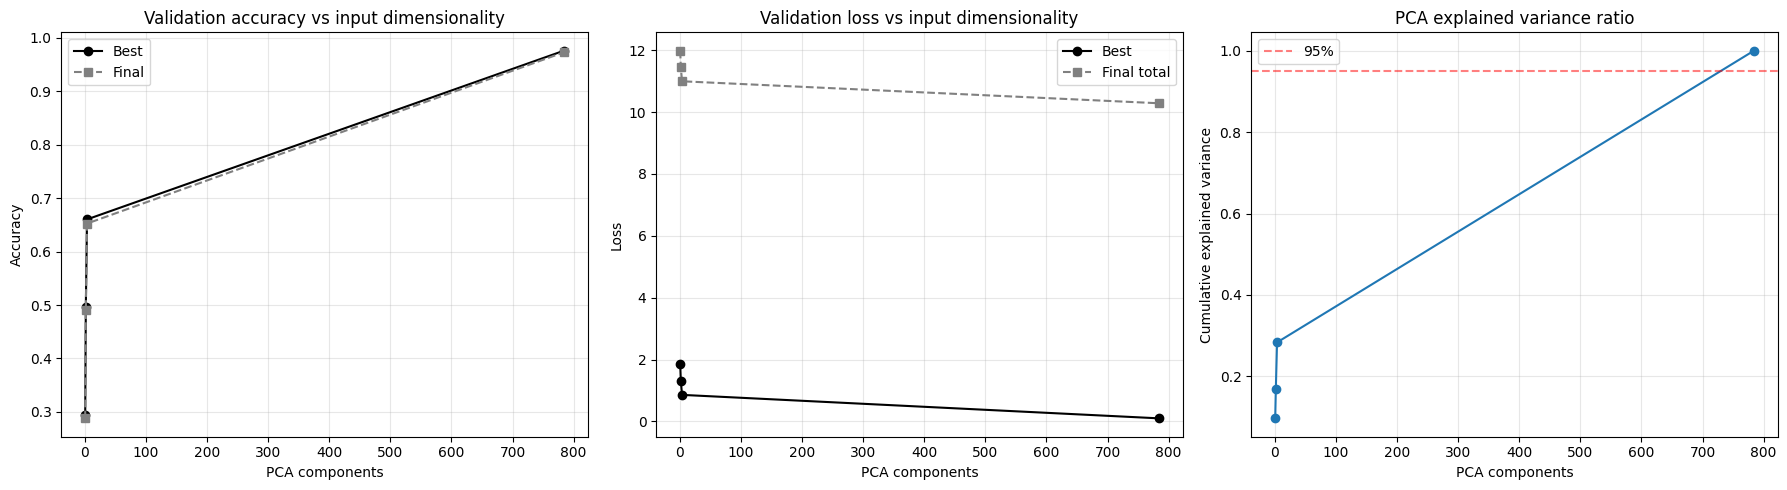

In [22]:
n_comp = [r["n_components"] for r in results]
exp_var = [r["explained_variance"] for r in results]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Accuracy vs n_components
ax = axes[0]
ax.plot(n_comp, [r["best_val_accuracy"] for r in results], "o-", color="black", label="Best")
ax.plot(n_comp, [r["final_val_accuracy"] for r in results], "s--", color="gray", label="Final")
ax.set_xlabel("PCA components")
ax.set_ylabel("Accuracy")
ax.set_title("Validation accuracy vs input dimensionality")
ax.legend()
ax.grid(True, alpha=0.3)

# CE loss vs n_components
ax = axes[1]
ax.plot(n_comp, [r["best_val_ce_loss"] for r in results], "o-", color="black", label="Best")
ax.plot(n_comp, [r["final_val_loss"] for r in results], "s--", color="gray", label="Final total")
ax.set_xlabel("PCA components")
ax.set_ylabel("Loss")
ax.set_title("Validation loss vs input dimensionality")
ax.legend()
ax.grid(True, alpha=0.3)

# Explained variance reference
ax = axes[2]
ax.plot(n_comp, exp_var, "o-", color="tab:blue")
ax.set_xlabel("PCA components")
ax.set_ylabel("Cumulative explained variance")
ax.set_title("PCA explained variance ratio")
ax.axhline(0.95, color="red", linestyle="--", alpha=0.5, label="95%")
ax.legend()
ax.grid(True, alpha=0.3)

fig.tight_layout()
fig.savefig(f"{exp_dir}/plots/pca_summary.png", dpi=150)
plt.show()

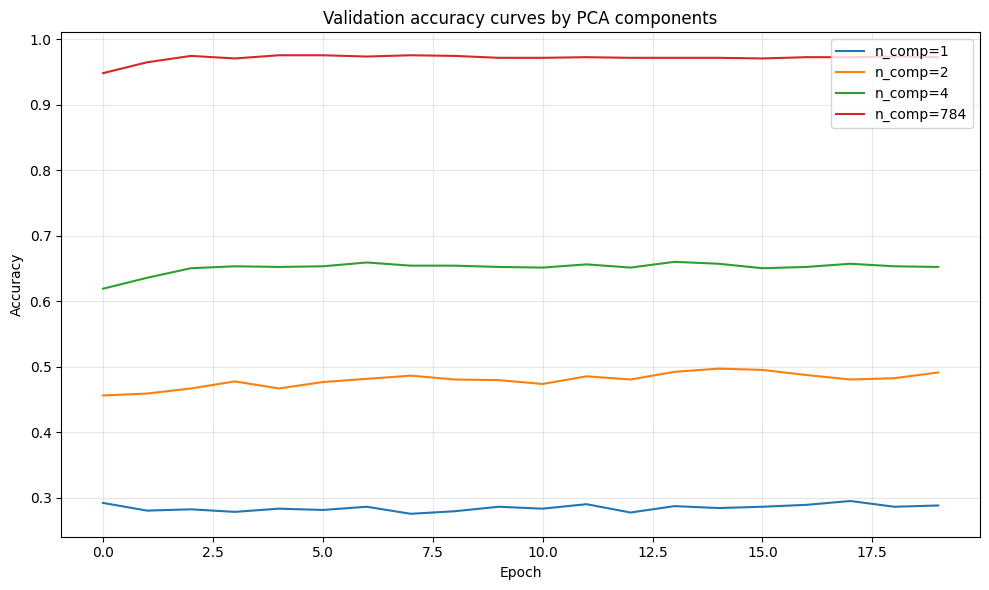

In [23]:
# Per-epoch accuracy curves colored by n_components
fig, ax = plt.subplots(figsize=(10, 6))
for r in results:
    acc = r["metrics"].get("validation_accuracy", [])
    if acc:
        ax.plot(acc, label=f"n_comp={r['n_components']}")
ax.set_xlabel("Epoch")
ax.set_ylabel("Accuracy")
ax.set_title("Validation accuracy curves by PCA components")
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig(f"{exp_dir}/plots/accuracy_curves.png", dpi=150)
plt.show()